In [ ]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("mexwell/crop-diseases-classification")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

Using Colab cache for faster access to the 'crop-diseases-classification' dataset.
Path to dataset files: /kaggle/input/crop-diseases-classification
Contents of base_path (/kaggle/input):
['crop-diseases-classification']
Contents of path (/kaggle/input/crop-diseases-classification):
['Data']


In [ ]:
import os

# Update path to match 'Data' directory found in the crop diseases dataset
data_path = os.path.join(path, 'Data')

# List subdirectories in Data (usually class labels)
if os.path.exists(data_path):
    print(f"Classes in dataset: {os.listdir(data_path)}")
else:
    print(f"Directory not found: {data_path}")

Classes in dataset: ['label_num_to_disease_map.json', 'train_images', 'train.csv']



--- Sample Images from Dataset (/kaggle/input/crop-diseases-classification/Data) ---
Found 17938 images. Displaying 6 samples:


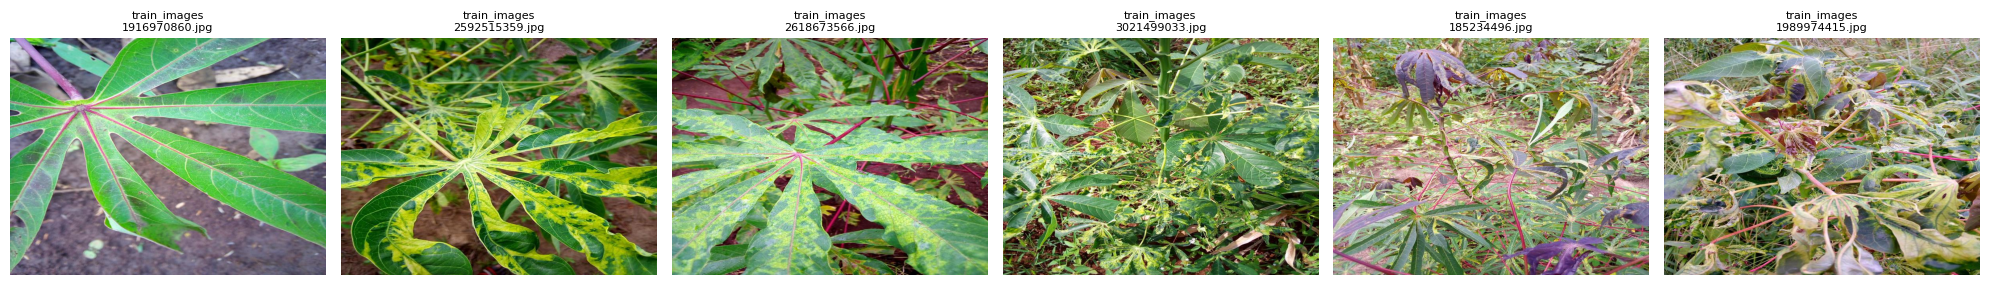

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images. Displaying {min(num_samples, len(all_image_paths))} samples:")

    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1:
        axes = [axes]

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            # Display class name (parent directory) and filename
            label = os.path.basename(os.path.dirname(img_path))
            axes[i].set_title(f"{label}\n{os.path.basename(img_path)}", fontsize=8)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Use the correct Data path
data_path = os.path.join(path, 'Data')
print(f"\n--- Sample Images from Dataset ({data_path}) ---")
display_sample_images(data_path)

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Paths to the CSV file and the image directory
csv_path = os.path.join(data_path, 'train.csv')
image_dir = os.path.join(data_path, 'train_images')

# Read data from CSV
df = pd.read_csv(csv_path)

# Split the dataset into 80% train and 20% test
# stratify=df['label'] ensures the proportion of crop disease classes is maintained in both sets
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

print(f"Total samples in 'train_images': {len(df)}")
print(f"Number of training samples: {len(train_df)}")
print(f"Number of test samples: {len(test_df)}")

# Display the first few rows of the training set for verification
display(train_df.head())

Total samples in 'train_images': 21397
Number of training samples: 17117
Number of test samples: 4280


,image_id,label
1715,1300823152.jpg,4
11830,3116613979.jpg,3
8621,2530012971.jpg,3
3849,1686186154.jpg,3
12924,3312736716.jpg,1


In [ ]:
import tensorflow as tf

# Check if GPU is available and list devices
print("TensorFlow version:", tf.__version__)
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  print('GPU device not found. Please enable GPU in Notebook Settings.')
else:
  print('Found GPU at: {}'.format(device_name))

# Verify physical devices
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        print("Name:", gpu.name, "  Type:", gpu.device_type)

TensorFlow version: 2.20.0
Found GPU at: /device:GPU:0
Name: /physical_device:GPU:0   Type: GPU


In [ ]:
from tensorflow.keras.applications import MobileNet
from tensorflow.keras import layers, models

# Get number of unique classes
num_classes = df['label'].nunique()

def build_model(num_classes):
    base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False  # Freeze base model layers

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_model(num_classes)
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenet_1.00_224 (Functional) │ (None, 7, 7, 1024)     │     3,228,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,492,549 (13.32 MB)

 Trainable params: 263,685 (1.01 MB)

 Non-trainable params: 3,228,864 (12.32 MB)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Prepare data generators
# Convert label to string as flow_from_dataframe requires categorical or string labels
train_df['label_str'] = train_df['label'].astype(str)
test_df['label_str'] = test_df['label'].astype(str)

train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=20, horizontal_flip=True)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=image_dir,
    x_col="image_id",
    y_col="label_str",
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse'
)

validation_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory=image_dir,
    x_col="image_id",
    y_col="label_str",
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse'
)

# Train the model
print("Starting training...")
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

Found 14342 validated image filenames belonging to 5 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:918: UserWarning: Found 2775 invalid image filename(s) in x_col="image_id". These filename(s) will be ignored.
  warnings.warn(


Found 3596 validated image filenames belonging to 5 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:918: UserWarning: Found 684 invalid image filename(s) in x_col="image_id". These filename(s) will be ignored.
  warnings.warn(


Starting training...
Epoch 1/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 280s 611ms/step - accuracy: 0.6775 - loss: 0.9043 - val_accuracy: 0.7175 - val_loss: 0.7607
Epoch 2/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 230s 513ms/step - accuracy: 0.7095 - loss: 0.7948 - val_accuracy: 0.7216 - val_loss: 0.7542
Epoch 3/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 232s 517ms/step - accuracy: 0.7203 - loss: 0.7673 - val_accuracy: 0.7367 - val_loss: 0.7224
Epoch 4/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 226s 504ms/step - accuracy: 0.7319 - loss: 0.7408 - val_accuracy: 0.7408 - val_loss: 0.7286
Epoch 5/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 227s 505ms/step - accuracy: 0.7355 - loss: 0.7288 - val_accuracy: 0.7339 - val_loss: 0.7036
Epoch 6/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 225s 501ms/step - accuracy: 0.7359 - loss: 0.7270 - val_accuracy: 0.7433 - val_loss: 0.7022
Epoch 7/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 227s 506ms/step - accuracy: 0.7410 - loss: 0.7016 - val_accuracy: 0.7453 - val_loss: 0.7024
Epoch 8/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 223s 497ms/step

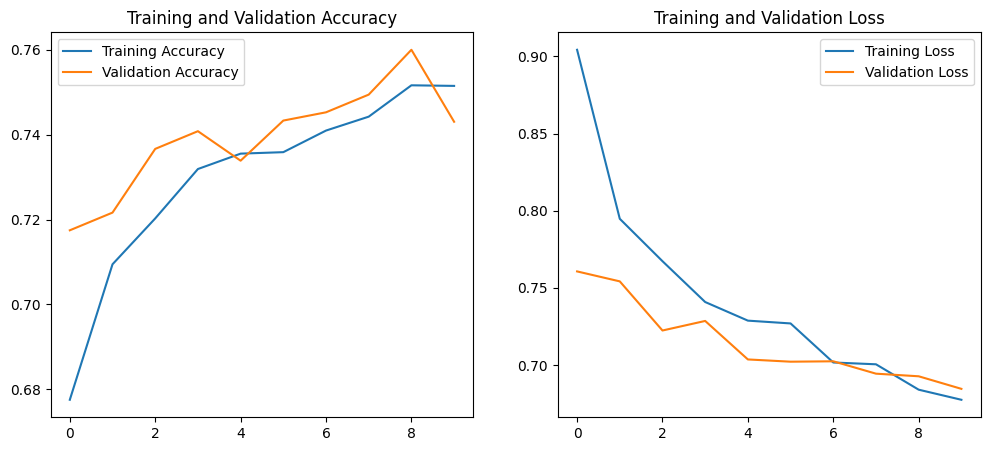

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.legend()

    plt.show()

plot_history(history)